In [1]:
import sys
from pathlib import Path
import os
import time
import glob
import itertools
import shutil
import matplotlib.pyplot as plt
import pandas as pd
import random
import numpy as np
from astropy.timeseries import LombScargle

PROJECT_ROOT = Path.cwd().parents[0]   # adjust if needed
sys.path.append(str(PROJECT_ROOT))

from src.jdr import jdr, jdr_parallel
from src.JDRKMedoids import JDRKMedoids
from src.JDRDBSCAN import JDRDBSCAN


In [2]:
PROJECT_ROOT

PosixPath('/home/franciscoperez/Documents/GitHub/JDR-Python')

In [3]:
# Directory containing .dat files
data_dir = "../data"

# Find RR Lyrae .dat files. Increase n_files if needed.
n_files = 50
files = sorted(glob.glob(os.path.join(data_dir, "*RRLYR*.dat")))[:n_files]

print(f"Found {len(files)} files")


Found 50 files


In [4]:
def read_light_curve(filepath, n_sample=100):
    # Read a light curve with columns time, magnitude, and optionally error.
    lc = pd.read_csv(filepath, sep=r"\s+", header=None, comment="#")
    if lc.shape[0]>n_sample:
        lc = lc.sample(n_sample)
    t = lc.iloc[:, 0].to_numpy(dtype=float)
    mag = lc.iloc[:, 1].to_numpy(dtype=float)
    err = lc.iloc[:, 2].to_numpy(dtype=float) if lc.shape[1] > 2 else None
    return t, mag, err


def estimate_period(dat_file, min_period=0.2, max_period=1.0, n_freq=20000):
    # Estimate the dominant period using Lomb--Scargle.
    t, mag, _ = read_light_curve(dat_file)
    mask = np.isfinite(t) & np.isfinite(mag)
    t = t[mask]
    mag = mag[mask]

    if len(t) < 5:
        raise ValueError(f"Not enough finite observations to estimate period: {dat_file}")

    freq = np.linspace(1 / max_period, 1 / min_period, n_freq)
    power = LombScargle(t, mag).power(freq)
    best_freq = freq[np.argmax(power)]
    return 1 / best_freq


def fold_time(t, period, t0=None):
    # Convert observation times to phase in [0, 1).
    if t0 is None:
        t0 = np.nanmin(t)
    return ((t - t0) / period) % 1.0


def write_folded_light_curve(input_file, output_dir, period=None, min_period=0.2, max_period=1.0):
    # Fold a light curve and write a JDR-compatible phase-space .dat file.
    t, mag, err = read_light_curve(input_file)

    if period is None:
        period = estimate_period(input_file, min_period=min_period, max_period=max_period)

    phase = fold_time(t, period)

    mask = np.isfinite(phase) & np.isfinite(mag)
    if err is not None:
        mask &= np.isfinite(err)

    phase = phase[mask]
    mag = mag[mask]
    err = err[mask] if err is not None else None

    order = np.argsort(phase)
    phase = phase[order]
    mag = mag[order]
    if err is not None:
        err = err[order]
        folded = np.column_stack([phase, mag, err])
    else:
        folded = np.column_stack([phase, mag])

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    output_file = output_dir / Path(input_file).name
    np.savetxt(output_file, folded, fmt="%.10f")
    return str(output_file), period


def build_folded_dataset(files, folded_dir="../data/folded_rrlyr", min_period=0.2, max_period=1.0, overwrite=True):
    # Create folded files and return their paths plus the estimated periods.
    folded_dir = Path(folded_dir)
    if overwrite and folded_dir.exists():
        shutil.rmtree(folded_dir)
    folded_dir.mkdir(parents=True, exist_ok=True)

    folded_files = []
    periods = {}

    for f in files:
        folded_f, period = write_folded_light_curve(
            f,
            output_dir=folded_dir,
            period=None,
            min_period=min_period,
            max_period=max_period,
        )
        folded_files.append(folded_f)
        periods[Path(f).stem] = period

    return folded_files, periods


folded_files, periods = build_folded_dataset(
    files,
    folded_dir="../data/folded_rrlyr",
    min_period=0.2,
    max_period=1.0,
    overwrite=True,
)

print(f"Created {len(folded_files)} folded files")
print("First folded file:", folded_files[0] if folded_files else None)


Created 50 folded files
First folded file: ../data/folded_rrlyr/OGLE-BLG-RRLYR-00001.dat


In [5]:
#df_results = pd.DataFrame(results, columns=['file1', 'file2', 'jdr', 'time'])

In [6]:
# Build JDR distance matrix using the folded light curves
D = JDRKMedoids.build_distance_matrix(
    files=folded_files,
    distance_func=jdr_parallel,   # or jdr
    verbose=True
)


Computed distances for pair (0, 20)
Computed distances for pair (0, 40)
Computed distances for pair (0, 49)
Computed distances for pair (1, 20)
Computed distances for pair (1, 40)
Computed distances for pair (1, 49)
Computed distances for pair (2, 20)
Computed distances for pair (2, 40)
Computed distances for pair (2, 49)
Computed distances for pair (3, 20)
Computed distances for pair (3, 40)
Computed distances for pair (3, 49)
Computed distances for pair (4, 20)
Computed distances for pair (4, 40)
Computed distances for pair (4, 49)
Computed distances for pair (5, 20)
Computed distances for pair (5, 40)
Computed distances for pair (5, 49)
Computed distances for pair (6, 20)
Computed distances for pair (6, 40)
Computed distances for pair (6, 49)
Computed distances for pair (7, 20)
Computed distances for pair (7, 40)
Computed distances for pair (7, 49)
Computed distances for pair (8, 20)
Computed distances for pair (8, 40)
Computed distances for pair (8, 49)
Computed distances for pair 

In [7]:
eps_values = np.linspace(0.01, 1, 10)
min_samples_values = [2, 3, 4]

for eps in eps_values:
    for min_samples in min_samples_values:
        model = JDRDBSCAN(eps=eps, min_samples=min_samples, verbose=False)
        model.fit(D)
        print(
            f"eps={eps:.4f}, min_samples={min_samples}, "
            f"clusters={model.n_clusters_}, noise={model.n_noise_}"
        )

eps=0.0100, min_samples=2, clusters=0, noise=50
eps=0.0100, min_samples=3, clusters=0, noise=50
eps=0.0100, min_samples=4, clusters=0, noise=50
eps=0.1200, min_samples=2, clusters=1, noise=48
eps=0.1200, min_samples=3, clusters=0, noise=50
eps=0.1200, min_samples=4, clusters=0, noise=50
eps=0.2300, min_samples=2, clusters=2, noise=46
eps=0.2300, min_samples=3, clusters=0, noise=50
eps=0.2300, min_samples=4, clusters=0, noise=50
eps=0.3400, min_samples=2, clusters=4, noise=42
eps=0.3400, min_samples=3, clusters=0, noise=50
eps=0.3400, min_samples=4, clusters=0, noise=50
eps=0.4500, min_samples=2, clusters=4, noise=40
eps=0.4500, min_samples=3, clusters=1, noise=46
eps=0.4500, min_samples=4, clusters=0, noise=50
eps=0.5600, min_samples=2, clusters=4, noise=37
eps=0.5600, min_samples=3, clusters=3, noise=39
eps=0.5600, min_samples=4, clusters=1, noise=45
eps=0.6700, min_samples=2, clusters=6, noise=32
eps=0.6700, min_samples=3, clusters=3, noise=38
eps=0.6700, min_samples=4, clusters=2, n

In [8]:
model = JDRDBSCAN(eps=0.8, min_samples=2, verbose=False)
labels = model.fit_predict(D)
print("Labels:", labels)
print("Number of clusters:", model.n_clusters_) 
print("Number of noise points:", model.n_noise_) 
print("Clusters:", model.clusters_)

Labels: [-1  0  1 -1 -1 -1  2 -1 -1  3  4  4 -1 -1  4 -1  4 -1 -1 -1  5 -1  2  6
  5 -1 -1  5 -1 -1 -1  6  2 -1 -1 -1 -1  4  0  4  5 -1 -1  6  3  1  7  6
 -1  7]
Number of clusters: 8
Number of noise points: 25
Clusters: [[1, 38], [2, 45], [6, 22, 32], [9, 44], [10, 11, 14, 16, 37, 39], [20, 24, 27, 40], [23, 31, 43, 47], [46, 49]]


In [9]:
data_dir

'../data'

In [10]:
cols = ["id", "field", "star_id", "type", "ra", "dec"]

df = pd.read_csv(
    os.path.join("/home/franciscoperez/Documents/GitHub/JDR-Python/notebooks/ident.dat"),
    sep=r"\s+",
    header=None,
    usecols=[0, 1, 2, 3, 4, 5],
    names=cols,
    engine="python"
)

df[['id', 'type']].head()

,id,type
0,OGLE-BLG-RRLYR-00001,RRab
1,OGLE-BLG-RRLYR-00002,RRc
2,OGLE-BLG-RRLYR-00003,RRab
3,OGLE-BLG-RRLYR-00004,RRab
4,OGLE-BLG-RRLYR-00005,RRab


In [11]:
files

['../data/OGLE-BLG-RRLYR-00001.dat',
 '../data/OGLE-BLG-RRLYR-00002.dat',
 '../data/OGLE-BLG-RRLYR-00003.dat',
 '../data/OGLE-BLG-RRLYR-00004.dat',
 '../data/OGLE-BLG-RRLYR-00005.dat',
 '../data/OGLE-BLG-RRLYR-00006.dat',
 '../data/OGLE-BLG-RRLYR-00007.dat',
 '../data/OGLE-BLG-RRLYR-00008.dat',
 '../data/OGLE-BLG-RRLYR-00009.dat',
 '../data/OGLE-BLG-RRLYR-00010.dat',
 '../data/OGLE-BLG-RRLYR-00011.dat',
 '../data/OGLE-BLG-RRLYR-00012.dat',
 '../data/OGLE-BLG-RRLYR-00013.dat',
 '../data/OGLE-BLG-RRLYR-00014.dat',
 '../data/OGLE-BLG-RRLYR-00015.dat',
 '../data/OGLE-BLG-RRLYR-00016.dat',
 '../data/OGLE-BLG-RRLYR-00017.dat',
 '../data/OGLE-BLG-RRLYR-00018.dat',
 '../data/OGLE-BLG-RRLYR-00019.dat',
 '../data/OGLE-BLG-RRLYR-00020.dat',
 '../data/OGLE-BLG-RRLYR-00021.dat',
 '../data/OGLE-BLG-RRLYR-00022.dat',
 '../data/OGLE-BLG-RRLYR-00023.dat',
 '../data/OGLE-BLG-RRLYR-00024.dat',
 '../data/OGLE-BLG-RRLYR-00025.dat',
 '../data/OGLE-BLG-RRLYR-00026.dat',
 '../data/OGLE-BLG-RRLYR-00027.dat',
 

In [12]:
cluster_files = [[files[idx] for idx in cluster] for cluster in model.clusters_]  # original files, labels from folded-distance clustering

objects_by_class = {}

print("\nFiles in each cluster:")
for k, cluster in enumerate(cluster_files):
    print(f"Cluster {k}:")
    objects = []
    for f in cluster:
        print("  ", f)
        objects.append(os.path.splitext(os.path.basename(f))[0])
    objects_by_class[str(k)] = objects


Files in each cluster:
Cluster 0:
   ../data/OGLE-BLG-RRLYR-00002.dat
   ../data/OGLE-BLG-RRLYR-00039.dat
Cluster 1:
   ../data/OGLE-BLG-RRLYR-00003.dat
   ../data/OGLE-BLG-RRLYR-00046.dat
Cluster 2:
   ../data/OGLE-BLG-RRLYR-00007.dat
   ../data/OGLE-BLG-RRLYR-00023.dat
   ../data/OGLE-BLG-RRLYR-00033.dat
Cluster 3:
   ../data/OGLE-BLG-RRLYR-00010.dat
   ../data/OGLE-BLG-RRLYR-00045.dat
Cluster 4:
   ../data/OGLE-BLG-RRLYR-00011.dat
   ../data/OGLE-BLG-RRLYR-00012.dat
   ../data/OGLE-BLG-RRLYR-00015.dat
   ../data/OGLE-BLG-RRLYR-00017.dat
   ../data/OGLE-BLG-RRLYR-00038.dat
   ../data/OGLE-BLG-RRLYR-00040.dat
Cluster 5:
   ../data/OGLE-BLG-RRLYR-00021.dat
   ../data/OGLE-BLG-RRLYR-00025.dat
   ../data/OGLE-BLG-RRLYR-00028.dat
   ../data/OGLE-BLG-RRLYR-00041.dat
Cluster 6:
   ../data/OGLE-BLG-RRLYR-00024.dat
   ../data/OGLE-BLG-RRLYR-00032.dat
   ../data/OGLE-BLG-RRLYR-00044.dat
   ../data/OGLE-BLG-RRLYR-00048.dat
Cluster 7:
   ../data/OGLE-BLG-RRLYR-00047.dat
   ../data/OGLE-BLG-RRLY

In [13]:
for cluster in objects_by_class.keys(): 
    print('Cluster: ', cluster)
    for light_curve in objects_by_class[cluster]: 
        print(df[df.id== light_curve]['type'].values[0])

Cluster:  0
RRc
RRd
Cluster:  1
RRab
RRab
Cluster:  2
RRc
RRc
RRc
Cluster:  3
RRab
RRab
Cluster:  4
RRc
RRc
RRc
RRc
RRc
RRc
Cluster:  5
RRab
RRab
RRc
RRab
Cluster:  6
RRc
RRc
RRc
RRc
Cluster:  7
RRab
RRab


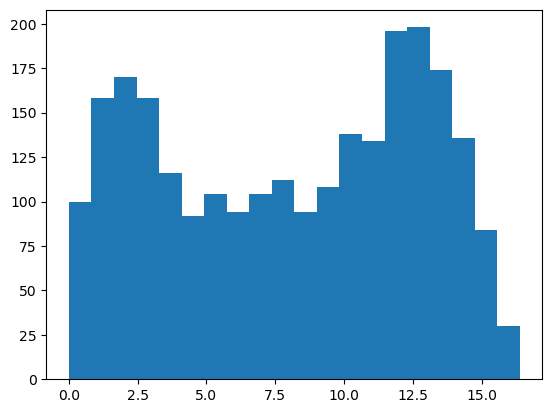

In [14]:
plt.hist(D.reshape(-1), bins=20)
plt.show()

In [15]:
files
labels = []
for light_curve in files: 
    labels.append(df[df.id==os.path.splitext(os.path.basename(light_curve))[0]]['type'].values[0])


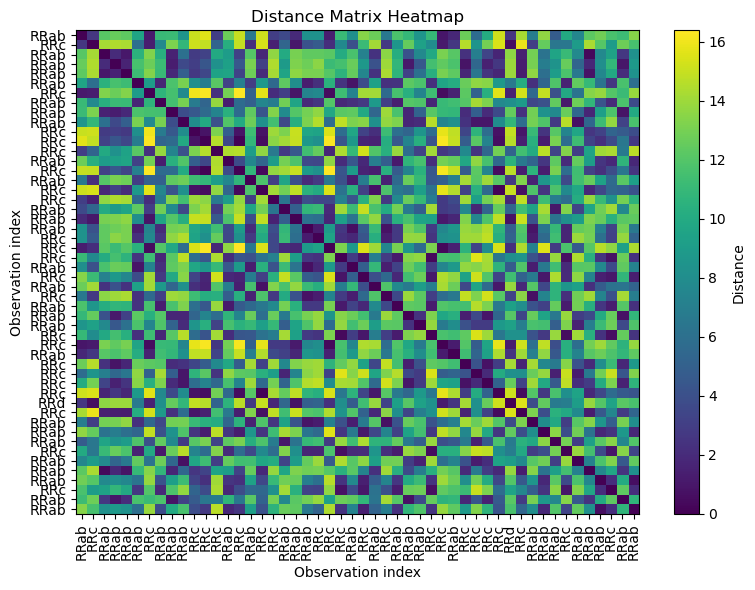

In [16]:
plt.figure(figsize=(8, 6))
im = plt.imshow(D, aspect="auto")
plt.colorbar(im, label="Distance")
plt.title("Distance Matrix Heatmap")
plt.xlabel("Observation index")
plt.ylabel("Observation index")

plt.xticks(ticks=range(len(labels)), labels=labels, rotation=90)
plt.yticks(ticks=range(len(labels)), labels=labels)

plt.tight_layout()
plt.show()

In [17]:
def plot_original_and_folded(filepath, period=None, star_name=None):
    # Plot original observations and the folded phase-space representation.
    t, mag, err = read_light_curve(filepath)
    if period is None:
        period = periods.get(Path(filepath).stem, None)
    if period is None:
        period = estimate_period(filepath)

    phase = fold_time(t, period)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    if err is not None:
        axes[0].errorbar(t, mag, yerr=err, fmt=".", alpha=0.7)
    else:
        axes[0].plot(t, mag, ".", alpha=0.7)

    axes[0].set_title(f"Original: {star_name or Path(filepath).stem}")
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("Magnitude")
    axes[0].invert_yaxis()
    axes[0].grid(alpha=0.3)

    if err is not None:
        axes[1].errorbar(phase, mag, yerr=err, fmt=".", alpha=0.7)
        axes[1].errorbar(phase + 1, mag, yerr=err, fmt=".", alpha=0.7)
    else:
        axes[1].plot(phase, mag, ".", alpha=0.7)
        axes[1].plot(phase + 1, mag, ".", alpha=0.7)

    axes[1].set_title(f"Folded: {star_name or Path(filepath).stem}\nP = {period:.6f}")
    axes[1].set_xlabel("Phase")
    axes[1].set_ylabel("Magnitude")
    axes[1].invert_yaxis()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()



Cluster 0


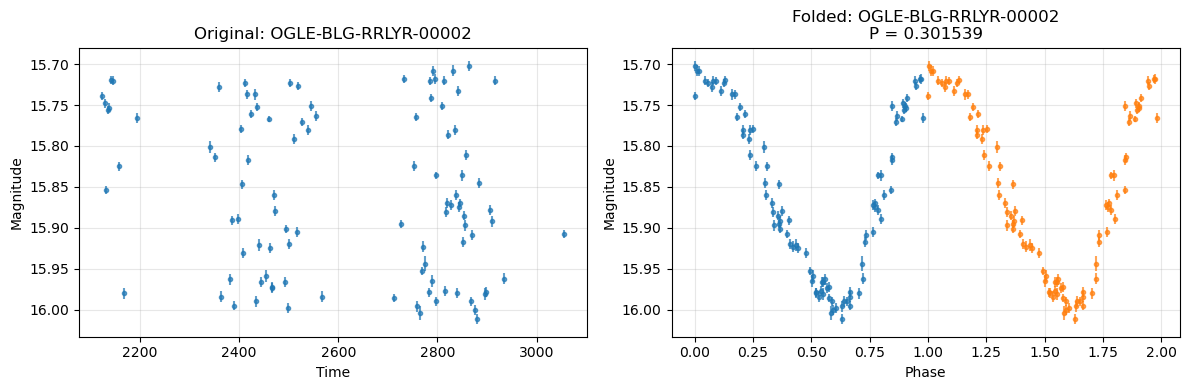

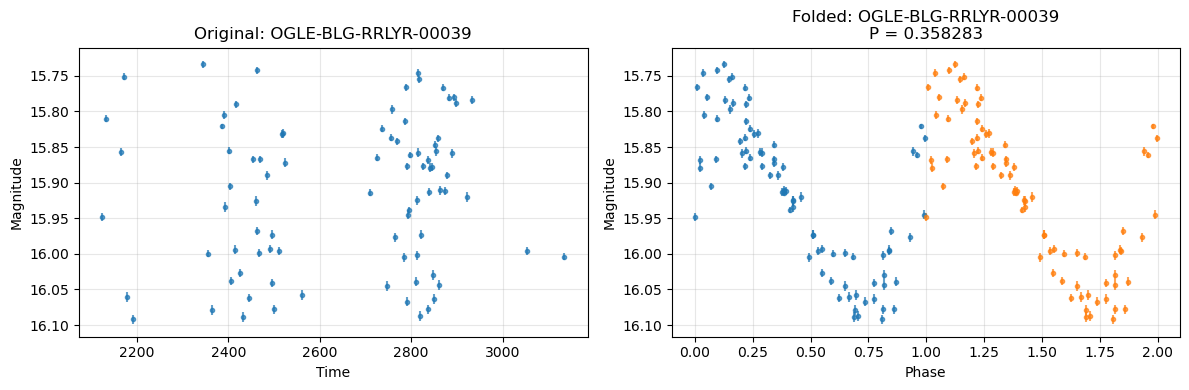


Cluster 1


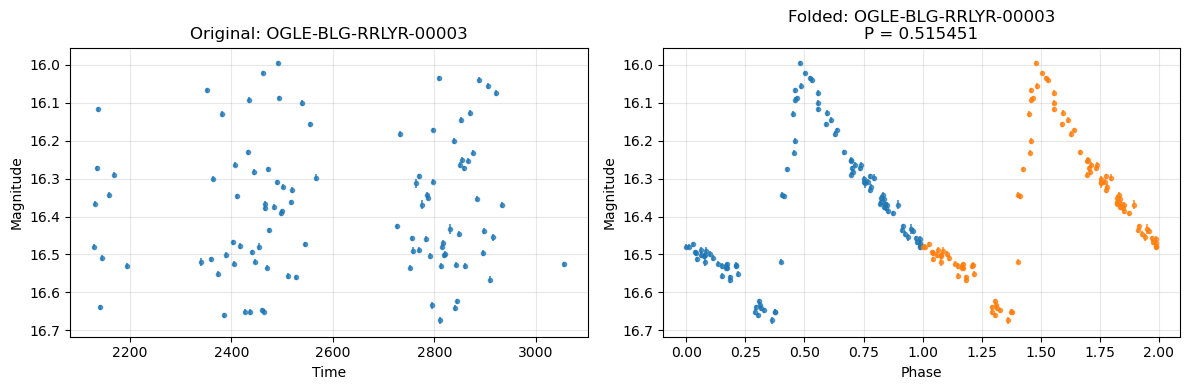

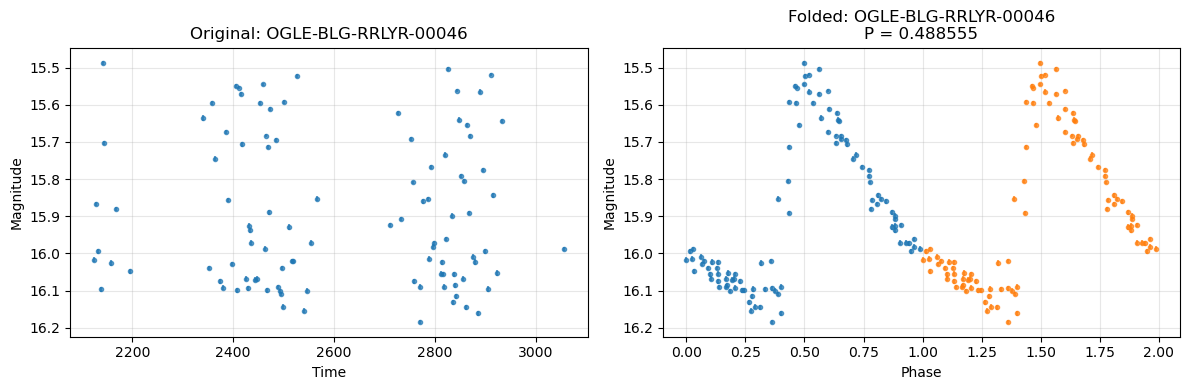


Cluster 2


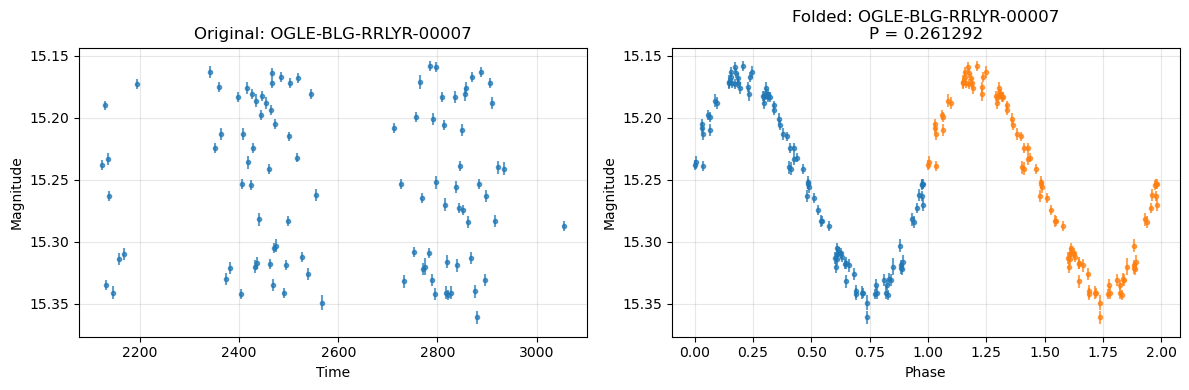

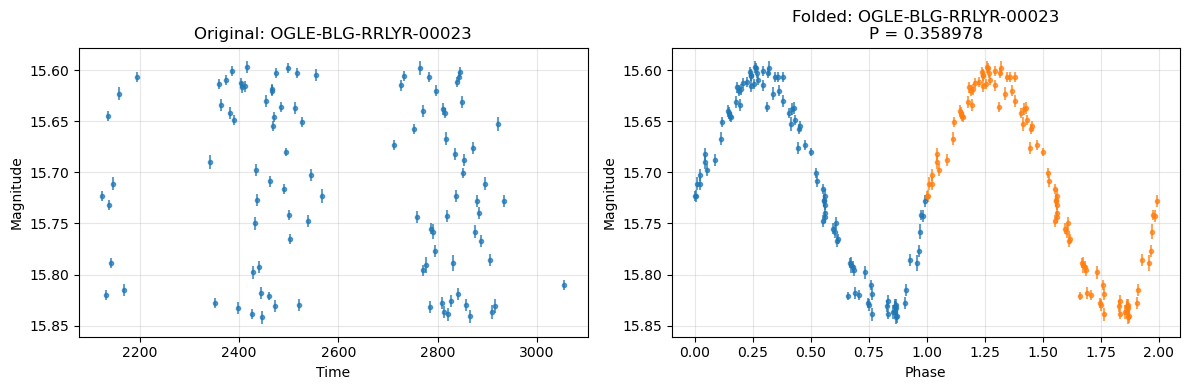

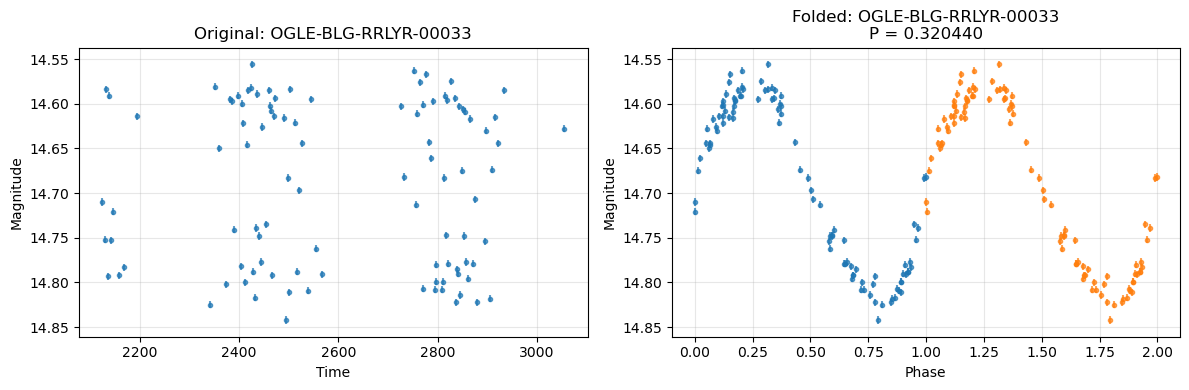


Cluster 3


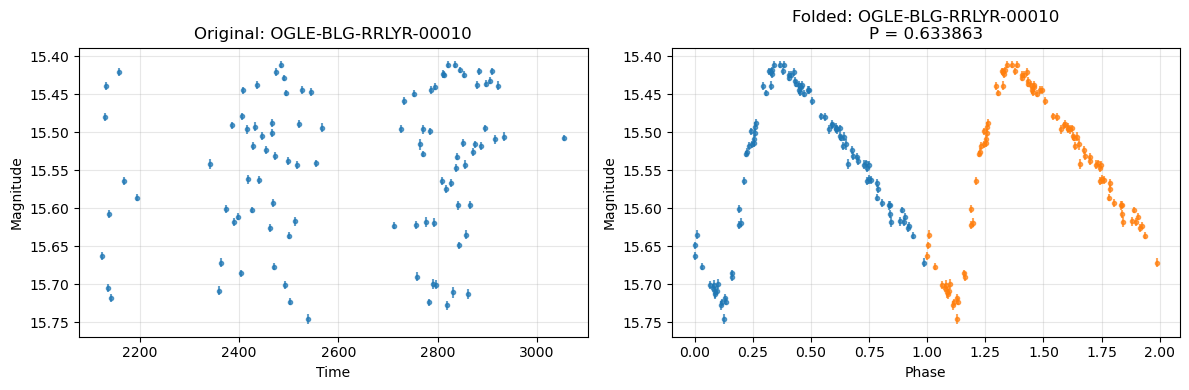

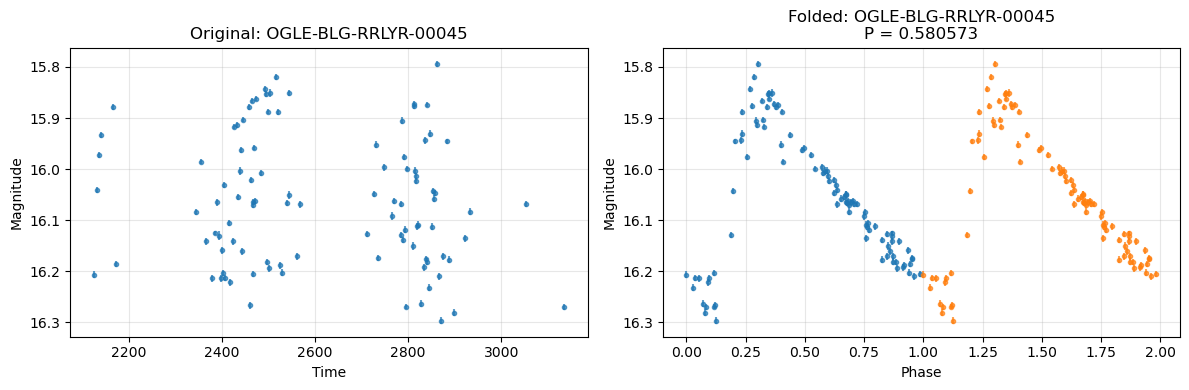


Cluster 4


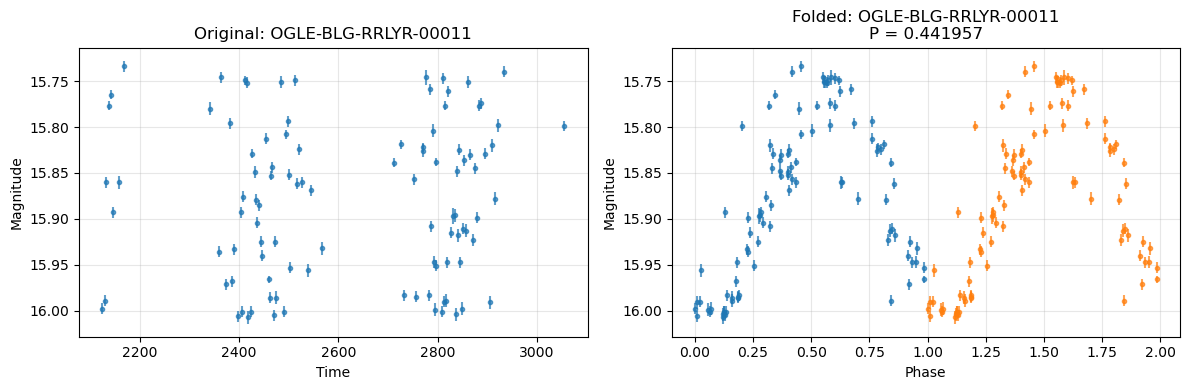

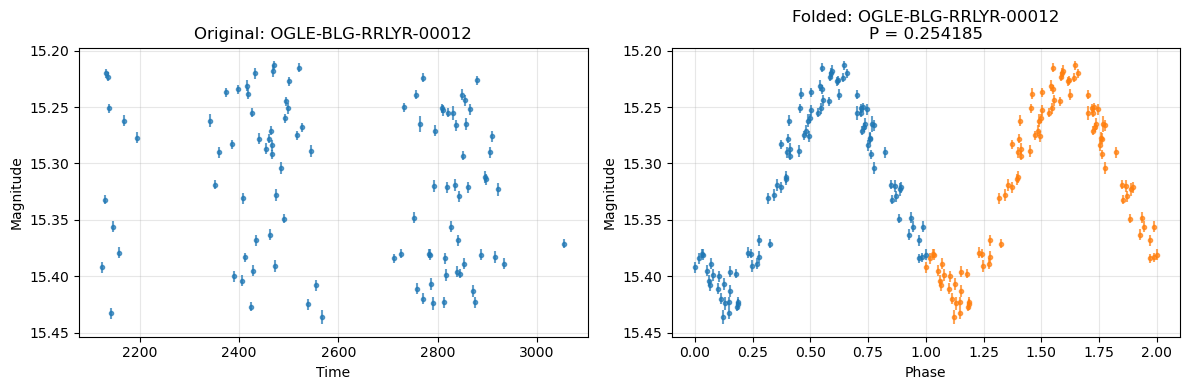

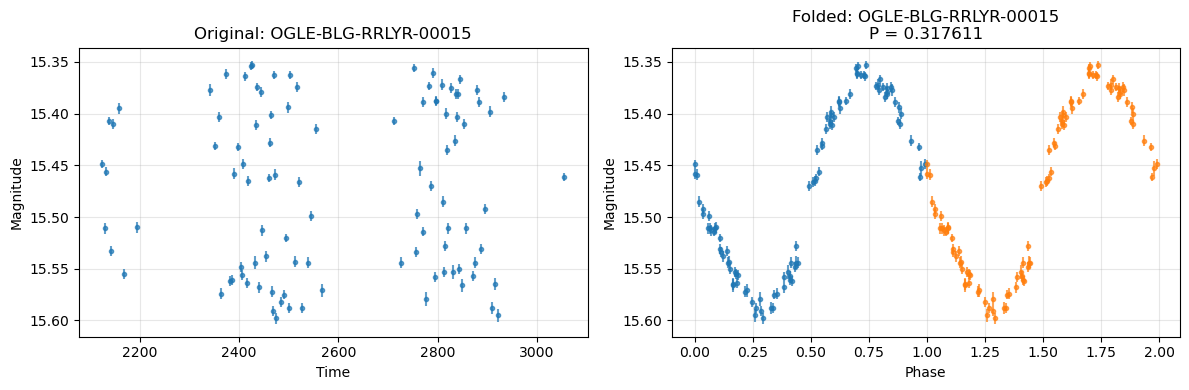

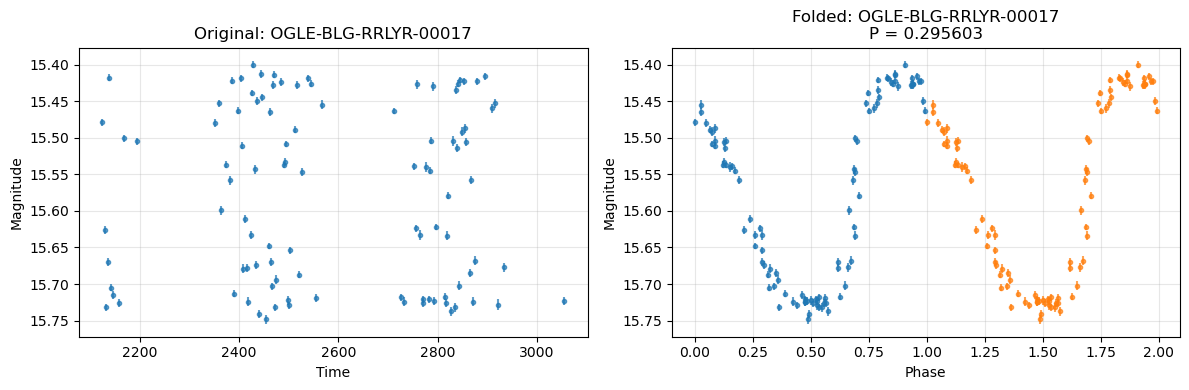

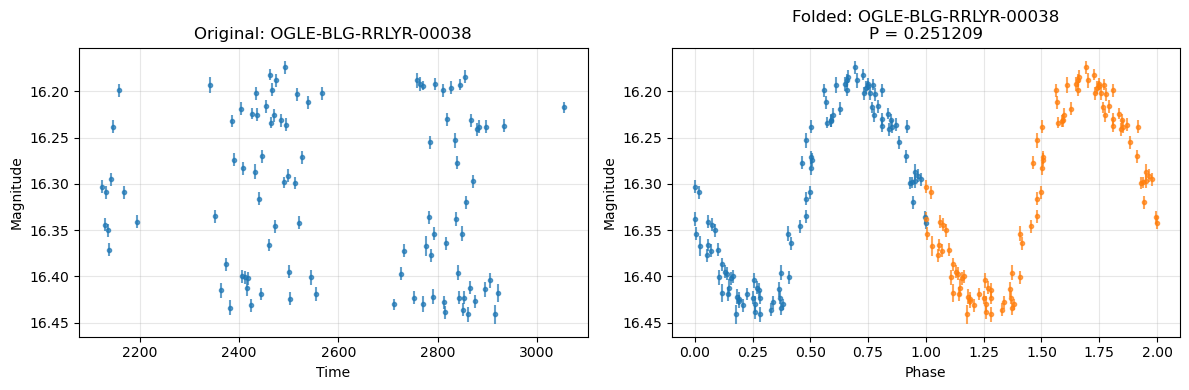

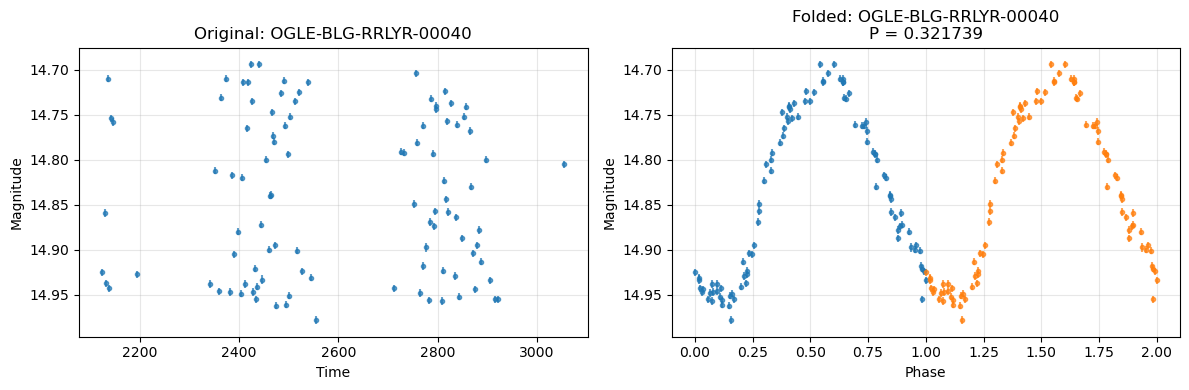


Cluster 5


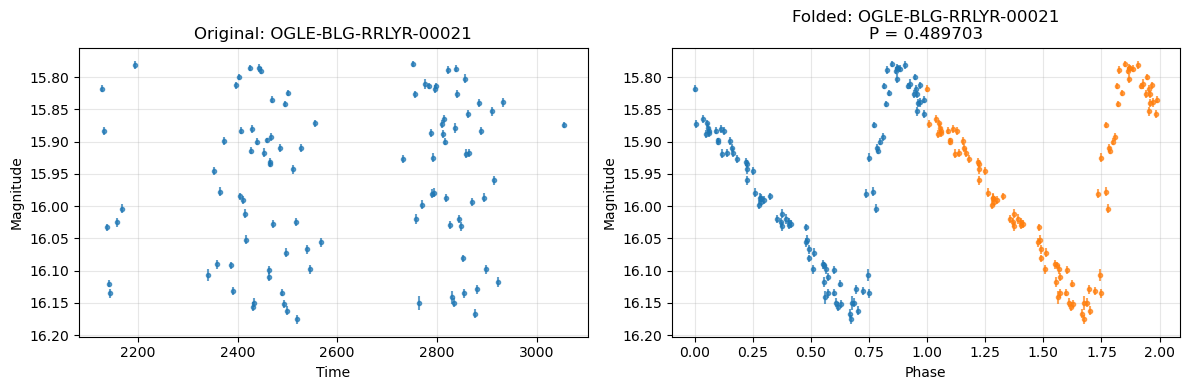

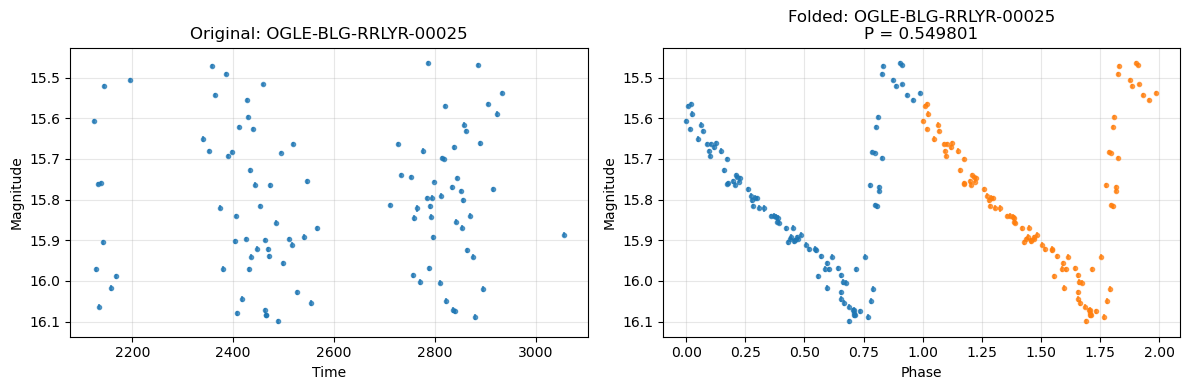

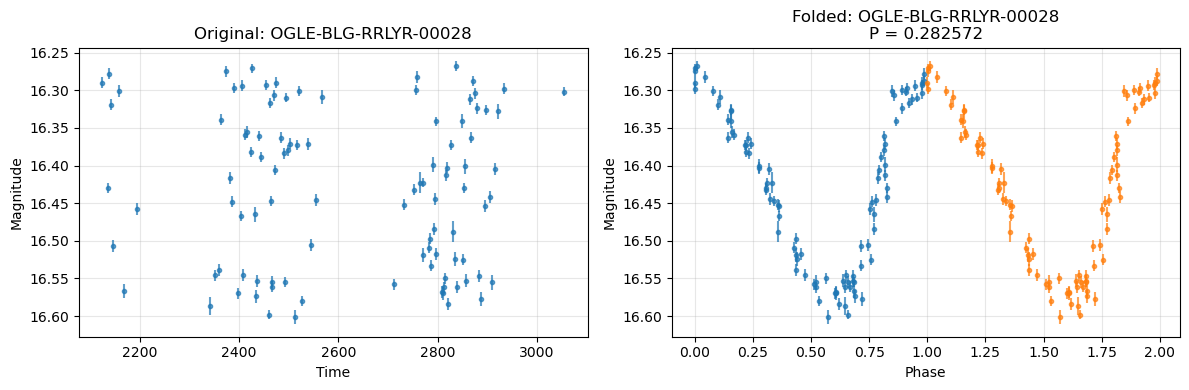

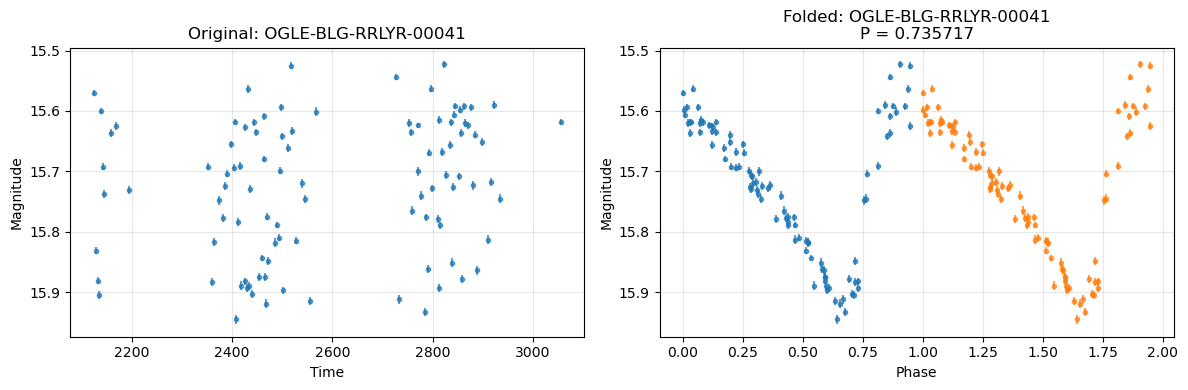


Cluster 6


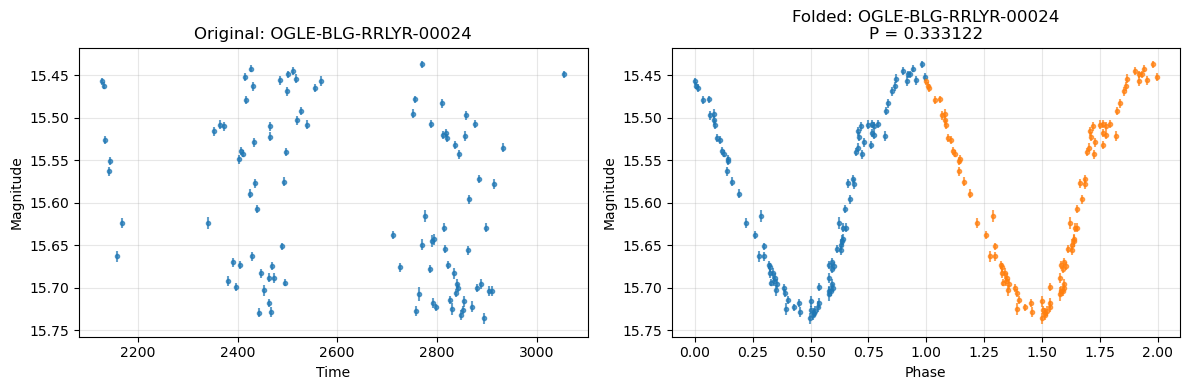

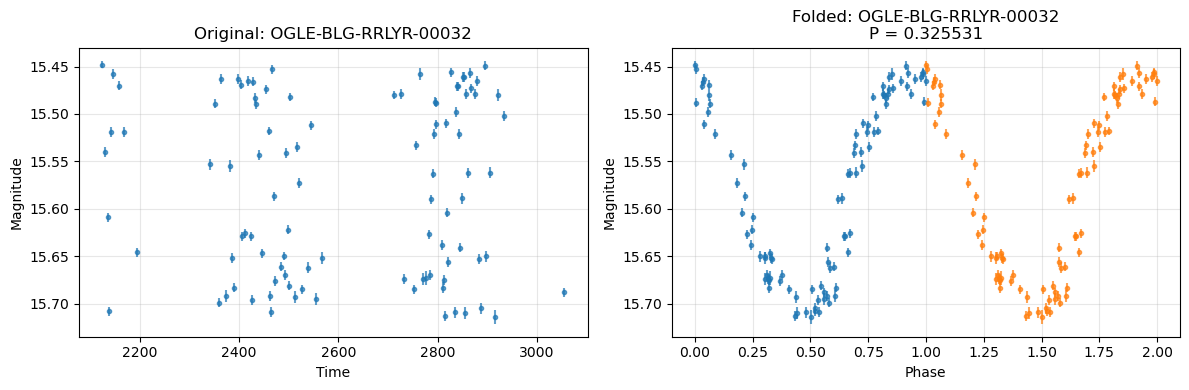

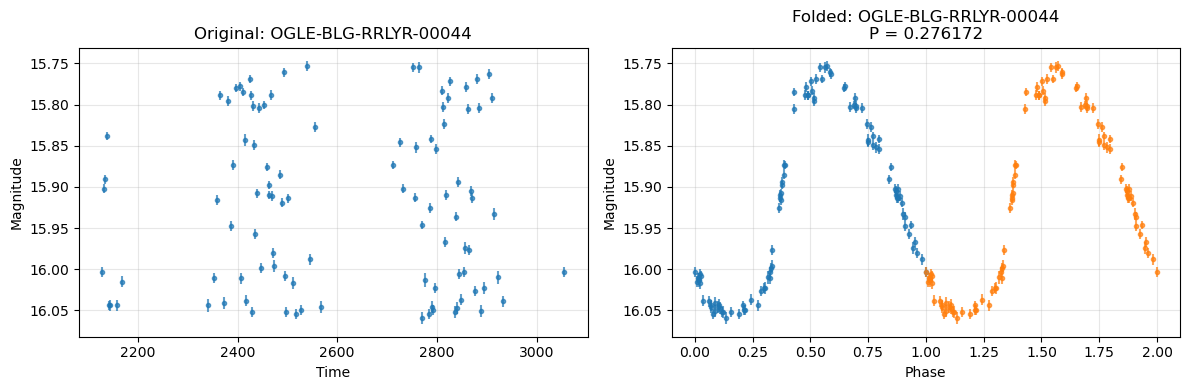

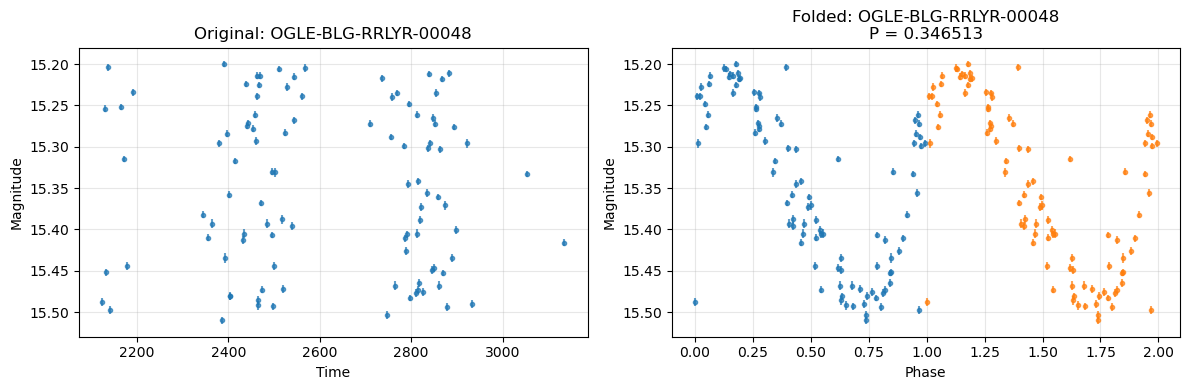


Cluster 7


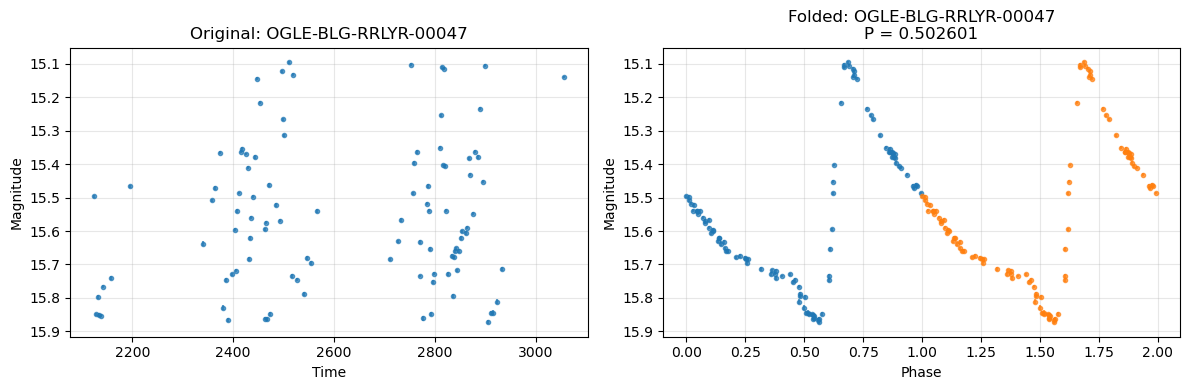

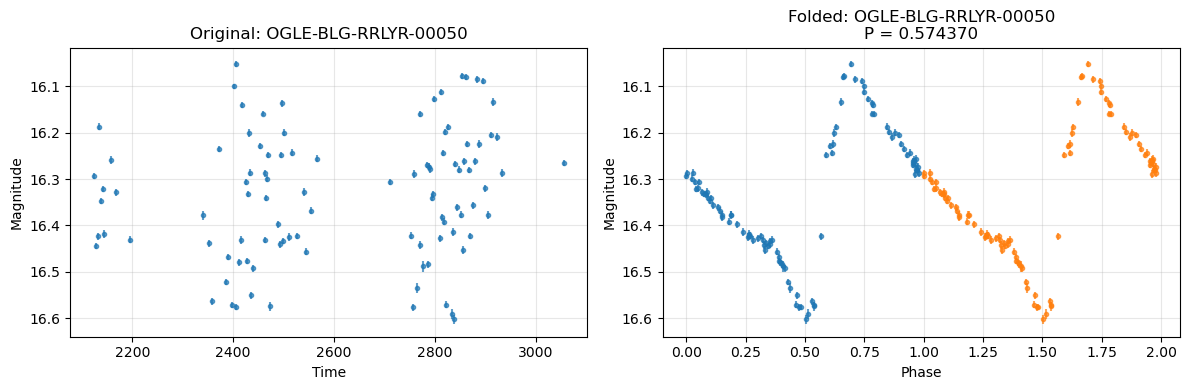

In [18]:
for cluster in objects_by_class.keys():
    print(f"\nCluster {cluster}")
    for star in objects_by_class[cluster]:
        filepath = f"../data/{star}.dat"
        period = periods.get(star, None)
        plot_original_and_folded(filepath, period=period, star_name=star)
